In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE


In [26]:
#config
#using multiple mat files will pool datasets
FILES = [
    "S09main_EpochedNoseRefCleanTimesFixed.mat",
    # "S07main_EpochedNoseRefCleanTimesFixed.mat",
    # "S08main_EpochedNoseRefCleanTimesFixed.mat",
]

FSAMPLE    = 512
T_STIMULUS = 822
T_PRE      = 822
T_POST     = 407
BANDS      = {"delta": (1, 4), "theta": (4, 8), "alpha": (8, 13), "beta": (13, 30)}

USE_SMOTE  = True #true = use smote


In [27]:
def get_field(struct, name):
    f = struct[name]
    if f.dtype == object:
        out = []
        for item in f.flatten():
            if isinstance(item, np.ndarray):
                out.append(item[0, 0] if item.size == 1 and item.ndim > 1 else (item[0] if item.size == 1 else item))
            else:
                out.append(item)
        return out
    return f.flatten() if f.size > 1 else f[0, 0]


def load_files(files):
    vals, trials = [], []
    for f in files:
        dc = loadmat(f)["dataClean"][0, 0]
        t  = np.array(get_field(dc, "trial"))
        ti = np.array(get_field(dc, "trialinfo")).reshape(len(t), 5)
        v  = ti[:, 1]
        vals.extend(v)
        trials.extend(t)
    trials = np.array(trials)
    vals   = np.array(vals)
    mask   = (vals != -1) & (vals != 0)
    return vals[mask] - 1, trials[mask]


y, all_trials = load_files(FILES)
X_full = all_trials.transpose(0, 2, 1)   # (trials, timesteps, channels)
print(f"Loaded files: {FILES}")
print(f"Trials: {len(y)}  |  Class 0: {(y==0).sum()}  Class 1: {(y==1).sum()}")


Loaded files: ['S09main_EpochedNoseRefCleanTimesFixed.mat']
Trials: 240  |  Class 0: 121  Class 1: 119


In [28]:
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

mean = X_tr_raw.mean(axis=(0, 1), keepdims=True)
std  = X_tr_raw.std(axis=(0, 1),  keepdims=True) + 1e-6
X_train = (X_tr_raw  - mean) / std
X_test  = (X_te_raw  - mean) / std
print(f"Train / Test: {len(y_train)} / {len(y_test)}")


Train / Test: 192 / 48


In [29]:
def band_powers(X):
    n, t, ch = X.shape
    feats = np.zeros((n, len(BANDS) * ch))
    for i in range(n):
        freqs, psd = welch(X[i], fs=FSAMPLE, axis=0, nperseg=min(256, t))
        bp = [psd[(freqs >= lo) & (freqs <= hi)].mean(axis=0) for lo, hi in BANDS.values()]
        feats[i] = np.concatenate(bp)
    return feats


def erp_features(X):
    s = FSAMPLE
    wins = [(0, int(0.2 * s)), (int(0.2 * s), int(0.4 * s)), (int(0.4 * s), X.shape[1])]
    return np.concatenate([X[:, a:b, :].mean(axis=1) for a, b in wins], axis=1)


def extract(X):
    return np.concatenate([band_powers(X), erp_features(X)], axis=1)


X_tr_pre  = X_train[:, :T_STIMULUS, :]
X_te_pre  = X_test[:,  :T_STIMULUS, :]
X_tr_post = X_train[:, T_STIMULUS:, :]
X_te_post = X_test[:,  T_STIMULUS:, :]

print("Extracting features...")
scaler_pre  = StandardScaler()
scaler_post = StandardScaler()

Xf_tr_pre  = scaler_pre.fit_transform(extract(X_tr_pre))
Xf_te_pre  = scaler_pre.transform(extract(X_te_pre))
Xf_tr_post = scaler_post.fit_transform(extract(X_tr_post))
Xf_te_post = scaler_post.transform(extract(X_te_post))

print(f"Pre-stimulus  feature shape: {Xf_tr_pre.shape}")
print(f"Post-stimulus feature shape: {Xf_tr_post.shape}")


Extracting features...
Pre-stimulus  feature shape: (192, 448)
Post-stimulus feature shape: (192, 448)


In [30]:
if USE_SMOTE:
    sm = SMOTE(random_state=42)
    Xf_tr_pre,  y_tr_pre  = sm.fit_resample(Xf_tr_pre,  y_train)
    Xf_tr_post, y_tr_post = sm.fit_resample(Xf_tr_post, y_train)
    print(f"Pre  SMOTE — Class 0: {(y_tr_pre==0).sum()}   Class 1: {(y_tr_pre==1).sum()}")
    print(f"Post SMOTE — Class 0: {(y_tr_post==0).sum()}  Class 1: {(y_tr_post==1).sum()}")
else:
    y_tr_pre  = y_train
    y_tr_post = y_train
    print("SMOTE not applied.")


Pre  SMOTE — Class 0: 98   Class 1: 98
Post SMOTE — Class 0: 98  Class 1: 98



  LR — Pre-stimulus + SMOTE
              precision    recall  f1-score   support

     Class 0     0.5556    0.5556    0.5556        27
     Class 1     0.4286    0.4286    0.4286        21

    accuracy                         0.5000        48
   macro avg     0.4921    0.4921    0.4921        48
weighted avg     0.5000    0.5000    0.5000        48



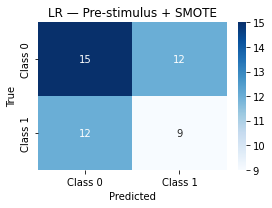


  LR — Post-stimulus + SMOTE
              precision    recall  f1-score   support

     Class 0     0.5833    0.5185    0.5490        27
     Class 1     0.4583    0.5238    0.4889        21

    accuracy                         0.5208        48
   macro avg     0.5208    0.5212    0.5190        48
weighted avg     0.5286    0.5208    0.5227        48



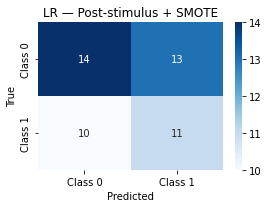

In [31]:
def show_results(name, y_true, y_pred):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["Class 0", "Class 1"], digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Class 0", "Class 1"],
                yticklabels=["Class 0", "Class 1"])
    plt.title(name); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()


smote_tag = " + SMOTE" if USE_SMOTE else ""

lr_pre = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_pre.fit(Xf_tr_pre, y_tr_pre)
show_results(f"LR — Pre-stimulus{smote_tag}", y_test, lr_pre.predict(Xf_te_pre))

lr_post = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_post.fit(Xf_tr_post, y_tr_post)
show_results(f"LR — Post-stimulus{smote_tag}", y_test, lr_post.predict(Xf_te_post))
